# **Exp**-**4** : **FSK**
# **Register** **Number** : **212224060182**
# **Name** : **Nivetika** **K**

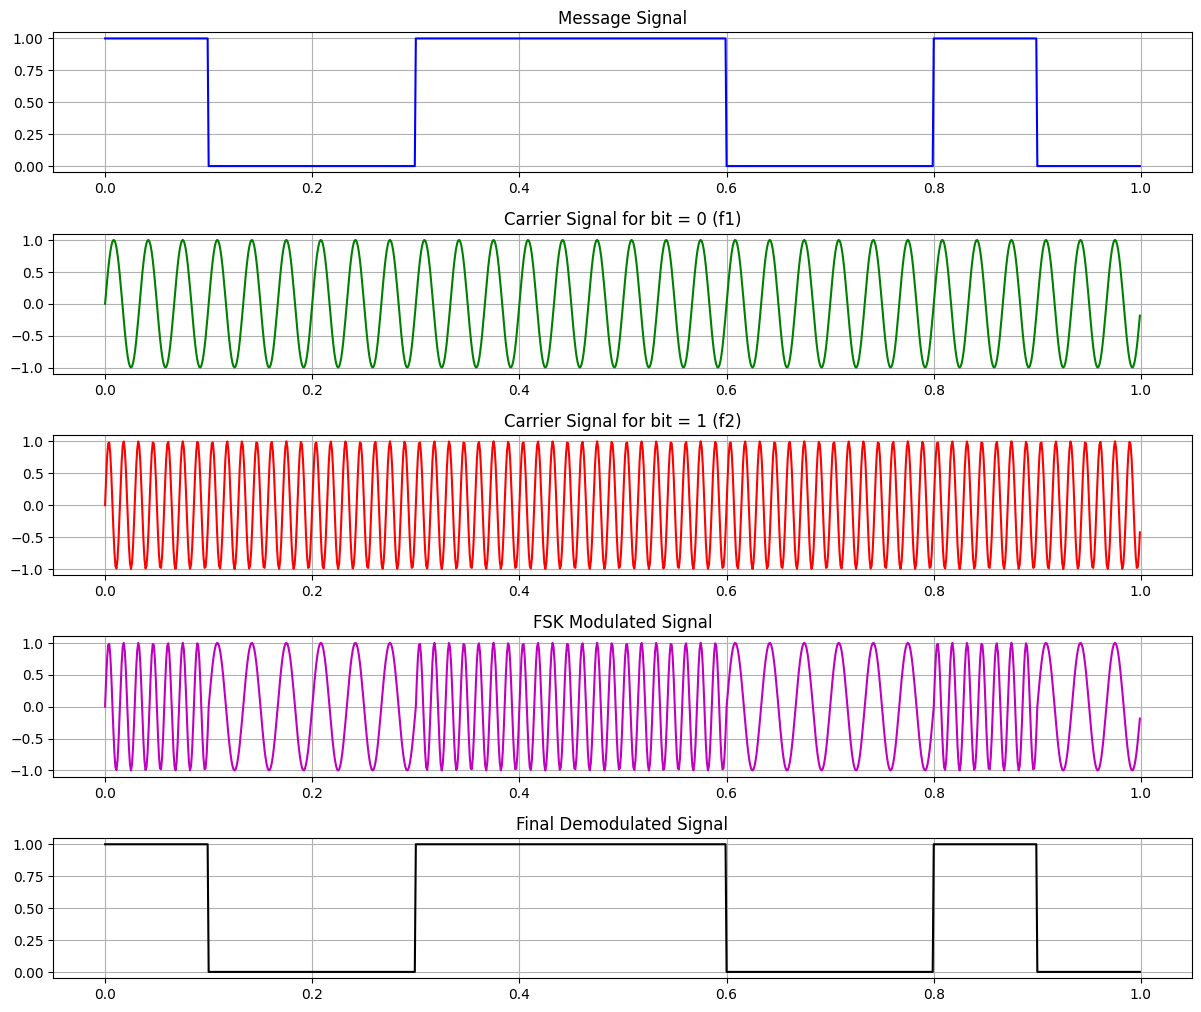

In [2]:
import matplotlib.pyplot as plt
from scipy.signal import butter, lfilter
import numpy as np

def butter_lowpass_filter(data, cutoff, fs, order=5):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return lfilter(b, a, data)

fs = 1000
f1 = 30
f2 = 70
bit_rate = 10
T = 1
t = np.linspace(0, T, int(fs * T), endpoint=False)

bits = np.random.randint(0, 2, bit_rate)
bit_duration = fs // bit_rate
message_signal = np.repeat(bits, bit_duration)

carrier_f1 = np.sin(2 * np.pi * f1 * t)
carrier_f2 = np.sin(2 * np.pi * f2 * t)

fsk_signal = np.zeros_like(t)
for i, bit in enumerate(bits):
    start = i * bit_duration
    end = start + bit_duration
    freq = f2 if bit else f1
    fsk_signal[start:end] = np.sin(2 * np.pi * freq * t[start:end])

ref_f1 = np.sin(2 * np.pi * f1 * t)
ref_f2 = np.sin(2 * np.pi * f2 * t)

corr_f1 = butter_lowpass_filter(fsk_signal * ref_f1, f2, fs)
corr_f2 = butter_lowpass_filter(fsk_signal * ref_f2, f2, fs)

decoded_bits = []
for i in range(bit_rate):
    start = i * bit_duration
    end = start + bit_duration
    energy_f1 = np.sum(corr_f1[start:end] ** 2)
    energy_f2 = np.sum(corr_f2[start:end] ** 2)
    decoded_bits.append(1 if energy_f2 > energy_f1 else 0)
decoded_bits = np.array(decoded_bits)
demodulated_signal = np.repeat(decoded_bits, bit_duration)

plt.figure(figsize=(12, 12))

plt.subplot(6, 1, 1)
plt.plot(t, message_signal, color='b')
plt.title('Message Signal')
plt.grid(True)

plt.subplot(6, 1, 2)
plt.plot(t, carrier_f1, color='g')
plt.title('Carrier Signal for bit = 0 (f1)')
plt.grid(True)

plt.subplot(6, 1, 3)
plt.plot(t, carrier_f2, color='r')
plt.title('Carrier Signal for bit = 1 (f2)')
plt.grid(True)

plt.subplot(6, 1, 4)
plt.plot(t, fsk_signal, color='m')
plt.title('FSK Modulated Signal')
plt.grid(True)

plt.subplot(6, 1, 5)
plt.plot(t, demodulated_signal, color='k')
plt.title('Final Demodulated Signal')
plt.grid(True)

plt.tight_layout()
plt.show()